# Single-shot profile tracking and actuators (paper figures)

Based on `generate_profile_report.py`. Adjust **shot**, **profile type**, targets, and τ in the parameters cell.

- **ρ panels**: 2×2 tracking at ρ ∈ {0.1, 0.3, 0.5, 0.7}. By default ρ is **normalized ψ<sub>N</sub>** on [0, 1], matching the uniform 33-point grid after `convert_profiles_101_to_33`. Set `RHO_CONVENTION = "sqrt_psi"` if your ρ is √(ψ<sub>N</sub>).
- **Actuators**: same signals as the PDF report; **gasA is raw (no low-pass)**. All other channels use the adjustable actuator τ.

In [134]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Publication-oriented defaults (no LaTeX requirement)
mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.25,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "mathtext.fontset": "stix",
    }
)

In [135]:
import MDSplus

from gadata import gadata

from generate_profile_report import (
    ACTUATOR_SIGNALS,
    OFF_AXIS_BEAMS,
    ON_AXIS_BEAMS,
    apply_lp_filter,
    build_target_trace,
    fetch_profile_signals,
    load_targets,
    validate_shot_config,
)

# After raw fetch we only carry merged beam sums + gas + ECH (LP / downsampling use these keys).
PIPELINE_ACTUATOR_SIGNALS = ("on_axis_pwr", "off_axis_pwr", "gasA", "echpwrc")


def rho_to_radial_index(rho: float, n_radial: int = 33, convention: str = "psi_n") -> int:
    """Map ρ to index on the uniform ψ_N grid used by CKXOUT → 33 points.

    Parameters
    ----------
    convention
        ``psi_n`` — ρ is normalized ψ_N ∈ [0, 1].
        ``sqrt_psi`` — ρ = √(ψ_N) (toroidal flux minor-radius labeling).
    """
    if convention == "psi_n":
        psi_n = float(rho)
    elif convention == "sqrt_psi":
        psi_n = float(rho) ** 2
    else:
        raise ValueError(convention)
    idx = int(np.round(psi_n * (n_radial - 1)))
    return int(np.clip(idx, 0, n_radial - 1))


ActuatorSeries = dict[str, tuple[np.ndarray, np.ndarray]]  # signal -> (time, data)


def _sum_beams_raw(
    by_sig: dict[str, tuple[np.ndarray, np.ndarray]], beams: set[str]
) -> tuple[np.ndarray, np.ndarray]:
    """Sum beam powers onto the first beam's time base (linear interp if grids differ)."""
    ordered = [s for s in ACTUATOR_SIGNALS if s in beams]
    if not ordered:
        raise ValueError("empty beam set")
    t_ref = np.asarray(by_sig[ordered[0]][0], dtype=float)
    y_sum = np.asarray(by_sig[ordered[0]][1], dtype=float).copy()
    for s in ordered[1:]:
        t = np.asarray(by_sig[s][0], dtype=float)
        y = np.asarray(by_sig[s][1], dtype=float)
        if t.shape == t_ref.shape and np.allclose(
            t, t_ref, rtol=1e-6, atol=1e-4, equal_nan=False
        ):
            y_sum = y_sum + y
        else:
            y_sum = y_sum + np.interp(t_ref, t, y, left=np.nan, right=np.nan)
    return t_ref, y_sum


def default_actuator_tau_k(k: float = 75.0) -> dict[str, float]:
    """Same multiplier ``k`` for every pipeline actuator channel."""
    return {s: float(k) for s in PIPELINE_ACTUATOR_SIGNALS}


def _resolve_actuator_tau_k(
    tau_k: float | dict[str, float], *, default_k: float = 75.0
) -> dict[str, float]:
    """Per-channel k for ``PIPELINE_ACTUATOR_SIGNALS`` (τ = k × Δt).

    Legacy keys: individual beam names (``bmspinj30l``, …) set ``on_axis_pwr`` /
    ``off_axis_pwr`` if those pipeline keys are absent.
    """
    if isinstance(tau_k, (int, float)):
        return {s: float(tau_k) for s in PIPELINE_ACTUATOR_SIGNALS}

    user = {str(k): float(v) for k, v in tau_k.items()}
    out = {s: default_k for s in PIPELINE_ACTUATOR_SIGNALS}

    if "on_axis_pwr" not in user:
        for s in ON_AXIS_BEAMS:
            if s in user:
                user.setdefault("on_axis_pwr", user[s])
                break
    if "off_axis_pwr" not in user:
        for s in OFF_AXIS_BEAMS:
            if s in user:
                user.setdefault("off_axis_pwr", user[s])
                break

    for name, val in user.items():
        if name in out:
            out[name] = float(val)

    return out


def fetch_actuator_raw(
    shot: int, connection: MDSplus.Connection | None = None
) -> ActuatorSeries:
    """Fetch beams, sum on/off-axis powers at raw rate, then attach gas + ECH."""
    conn = connection or MDSplus.Connection("atlas.gat.com")
    by_sig: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    for signal in ACTUATOR_SIGNALS:
        data = gadata(signal, shot, connection=conn)
        by_sig[signal] = (np.asarray(data.xdata), np.asarray(data.zdata))

    t_on, y_on = _sum_beams_raw(by_sig, ON_AXIS_BEAMS)
    t_off, y_off = _sum_beams_raw(by_sig, OFF_AXIS_BEAMS)

    return {
        "on_axis_pwr": (t_on, y_on),
        "off_axis_pwr": (t_off, y_off),
        "gasA": by_sig["gasA"],
        "echpwrc": by_sig["echpwrc"],
    }


def actuator_downsample(raw: ActuatorSeries, every: int = 20) -> ActuatorSeries:
    """Stride both time and data (same as ``x[::every]`` in the report pipeline)."""
    if every < 1:
        raise ValueError("every must be >= 1")
    return {sig: (t[::every], y[::every]) for sig, (t, y) in raw.items()}


def actuator_apply_lp(
    downsampled: ActuatorSeries,
    tau_k: float | dict[str, float],
    dt_ms: float,
    skip_lp_for_gas: bool = True,
    default_k: float = 75.0,
) -> ActuatorSeries:
    """LP each channel with τ = k × dt_ms (sample spacing after decimation).

    When ``skip_lp_for_gas`` is True, ``gasA`` is passed through unchanged.
    """
    tk = _resolve_actuator_tau_k(tau_k, default_k=default_k)
    out: ActuatorSeries = {}
    for signal in PIPELINE_ACTUATOR_SIGNALS:
        t, y = downsampled[signal]
        k = tk[signal]
        tau_ms = k * dt_ms
        if skip_lp_for_gas and signal == "gasA":
            y_f = np.asarray(y, dtype=float).copy()
        else:
            y_f = apply_lp_filter(np.asarray(y, dtype=float), dt=dt_ms, tau=tau_ms)
        out[signal] = (t, y_f)
    return out


def actuator_apply_lp_fullrate(
    raw: ActuatorSeries,
    tau_k: float | dict[str, float],
    skip_lp_for_gas: bool = True,
    default_k: float = 75.0,
) -> ActuatorSeries:
    """LP each channel with τ = k × Δt, Δt = median native sample spacing (before decimation)."""
    tk = _resolve_actuator_tau_k(tau_k, default_k=default_k)
    out: ActuatorSeries = {}
    for signal in PIPELINE_ACTUATOR_SIGNALS:
        t, y = raw[signal]
        t = np.asarray(t, dtype=float)
        y = np.asarray(y, dtype=float)
        dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
        k = tk[signal]
        tau_ms = k * dt
        if skip_lp_for_gas and signal == "gasA":
            y_f = y.copy()
        else:
            y_f = apply_lp_filter(y, dt=dt, tau=tau_ms)
        out[signal] = (t, y_f)
    return out


def actuator_aggregate(series: ActuatorSeries) -> dict:
    """Flatten to legacy plot keys (``on_axis_pwr``, ``*_time``, …)."""
    act_data: dict = {}
    for signal in PIPELINE_ACTUATOR_SIGNALS:
        x, y = series[signal]
        act_data[signal] = y
        act_data[f"{signal}_time"] = x
    return act_data


def fetch_actuator_data(
    shot: int,
    tau_k: float | dict[str, float] = 75.0,
    dt_ms: float = 20.0,
    downsample: int = 20,
    skip_lp_for_gas: bool = True,
    default_k: float = 75.0,
):
    """Pipeline: raw → downsample → LP (τ = k·Δt) → aggregate (gas may skip LP)."""
    raw = fetch_actuator_raw(shot)
    ds = actuator_downsample(raw, every=downsample)
    lp = actuator_apply_lp(
        ds,
        tau_k=tau_k,
        dt_ms=dt_ms,
        skip_lp_for_gas=skip_lp_for_gas,
        default_k=default_k,
    )
    return actuator_aggregate(lp)


In [162]:
# --- Single-shot configuration (edit here) ---
SHOT = 206590
PROF_TYPE = "rot"  # "rot" | "dens" | "pres" | "etemp"

TARGETS_DIR = Path(os.environ["HOME"]) / "rl_prof_control_exp" / "final_lp_targets"

# Must match ``generate_profile_report`` schema
SHOT_CONFIG = {
    "shot": SHOT,
    "prof_type": PROF_TYPE,
    "targets_indxs": [12,7,7],
    "target_set_times": [1500, 2500,3500,4100],
}

validate_shot_config(SHOT_CONFIG)

# Low-pass τ on profile traces (ms); same convention as ``--profile-tau``
PROFILE_TAU_MS = 20.0

# Per-channel LP after raw beam sums: τ = tau_k[name] × Δt. Names:
# ``on_axis_pwr``, ``off_axis_pwr`` (sums of PTDATA beams), ``gasA``, ``echpwrc``.
ACTUATOR_TAU_K = default_actuator_tau_k(75.0)
# Example overrides: PTDATA names from ``ACTUATOR_SIGNALS``, or group aliases
# ``on_axis_pwr`` / ``off_axis_pwr`` (apply one k to all beams in that sum).

# ACTUATOR_TAU_K["gasA"] = 0.0  # only meaningful if you disable skip_lp_for_gas

ACTUATOR_DOWNSAMPLE = 20

PLOT_START_TIME_MS = 1000.0
XLIM_MS = (0.0, 6000.0)

RHOS = (0.1, 0.3, 0.5, 0.7)
# How ρ maps to radial index (see docstring above)
RHO_CONVENTION = "psi_n"  # or "sqrt_psi"

# Optional PDF export
SAVE_PDF = True
OUT_DIR = Path("nips_26_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

X_LIMITS_MS = (500.0, 4100.0)


In [163]:
targets_by_type = load_targets(TARGETS_DIR)
targets = targets_by_type[PROF_TYPE]

times, profile_signals = fetch_profile_signals(
    shot=SHOT, prof_type=PROF_TYPE, tau=PROFILE_TAU_MS
)

target_set_times = SHOT_CONFIG["target_set_times"]
selected_target_indices = [idx - 1 for idx in SHOT_CONFIG["targets_indxs"]]
set_time_indices = [int(np.argmin(np.abs(times - t))) for t in target_set_times]
plot_start_idx = int(np.argmin(np.abs(times - PLOT_START_TIME_MS)))

actuator_raw = fetch_actuator_raw(SHOT)

print("Loaded shot", SHOT, PROF_TYPE, "| times", len(times), "| profile shape", profile_signals.shape)

Environment variable TOKSEARCH_INDEX_DIR not set.
Environment variable TOKSEARCH_INDEX_DIR not set.
Environment variable TOKSEARCH_INDEX_DIR not set.
Environment variable TOKSEARCH_INDEX_DIR not set.


   bmspinj30l fetched from PTDATA in 2.09s
   bmspinj30r fetched from PTDATA in 0.07s
   bmspinj33l fetched from PTDATA in 0.07s
   bmspinj33r fetched from PTDATA in 0.06s
   bmspinj15l fetched from PTDATA in 0.07s
   bmspinj15r fetched from PTDATA in 0.07s
   bmspinj21l fetched from PTDATA in 0.06s
   bmspinj21r fetched from PTDATA in 0.06s
   gasA fetched from PTDATA in 0.95s
   echpwrc fetched from MDSplus tree RF in 0.01s
Loaded shot 206590 rot | times 355 | profile shape (355, 33)


In [164]:
# Actuators: LP first at native spacing (τᵢ = kᵢ Δt), then decimation → ``act_data``.

ACTUATOR_TAU_K["echpwrc"] = 1000.0
ACTUATOR_TAU_K["on_axis_pwr"] = 500.0
ACTUATOR_TAU_K["off_axis_pwr"] = 1000.0

_act_lp = actuator_apply_lp_fullrate(
    actuator_raw, tau_k=ACTUATOR_TAU_K, skip_lp_for_gas=True
)
_act_ds = actuator_downsample(_act_lp, every=ACTUATOR_DOWNSAMPLE)
act_data = actuator_aggregate(_act_ds)

print(
    "Actuator pipeline: LP full-rate (τ = k·Δt) → downsample",
    "| stride",
    ACTUATOR_DOWNSAMPLE,
    "| act_data keys",
    len(act_data),
)


Actuator pipeline: LP full-rate (τ = k·Δt) → downsample | stride 20 | act_data keys 8


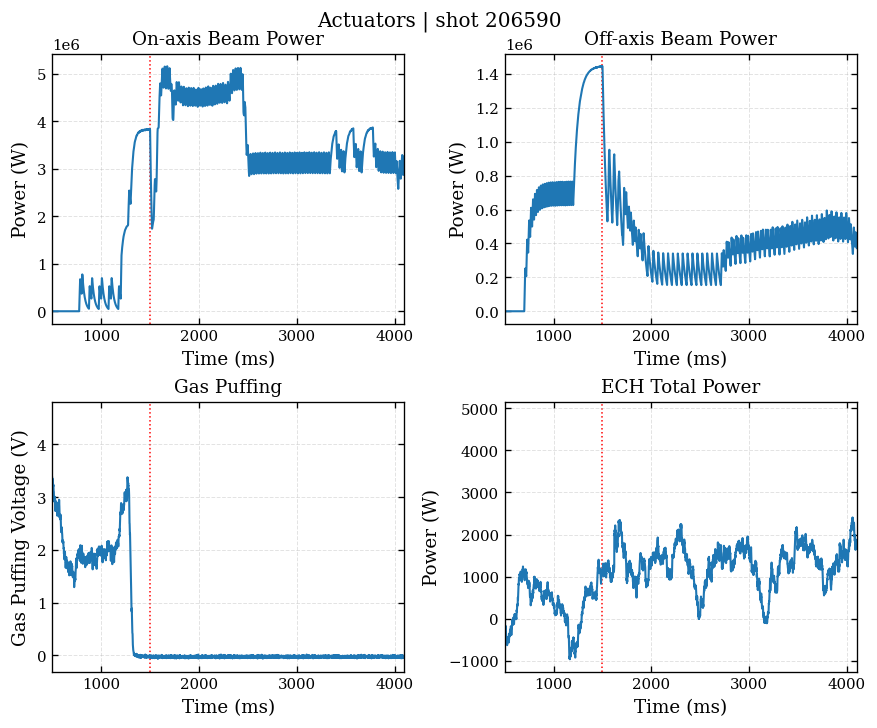

In [165]:
# Figure 2 — actuators (2×2); gas unfiltered; τᵢ = kᵢ Δt on merged beam sums
from tkinter import Y


fig2, axes = plt.subplots(2, 2, figsize=(7.2, 5.8), constrained_layout=True)
axes = axes.ravel()

panels = ["on_axis_pwr", "off_axis_pwr", "gasA", "echpwrc"]
_tk_disp = _resolve_actuator_tau_k(ACTUATOR_TAU_K)
# titles = {
#     "on_axis_pwr": fr"On-axis beam sum ($k = {_tk_disp['on_axis_pwr']:g}$)",
#     "off_axis_pwr": fr"Off-axis beam sum ($k = {_tk_disp['off_axis_pwr']:g}$)",
#     "gasA": "gasA (no LP)",
#     "echpwrc": fr"ECH ($k = {_tk_disp['echpwrc']:g}$)",
# }
titles = {
    "on_axis_pwr": "On-axis Beam Power",
    "off_axis_pwr": "Off-axis Beam Power",
    "gasA": "Gas Puffing",
    "echpwrc": "ECH Total Power",
}
y_labels = {
    "on_axis_pwr": "Power (W)",
    "off_axis_pwr": "Power (W)",
    "gasA": "Gas Puffing Voltage (V)",
    "echpwrc": "Power (W)",
}

for ax, key in zip(axes, panels):
    tx = act_data.get(f"{key}_time")
    yv = act_data.get(key)
    if tx is None or yv is None:
        ax.set_visible(False)
        continue
    ax.plot(tx, yv, color="C0")
    # for tset in target_set_times:
    #     ax.axvline(tset, color="0.75", linewidth=0.9, linestyle=":", zorder=0)
    ax.axvline(1500, color="red", linewidth=0.9, linestyle=":", zorder=0)
    
    ax.set_xlim(*XLIM_MS)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(y_labels[key])
    ax.set_title(titles[key])
    ax.grid(True, alpha=0.35, linestyle="--", linewidth=0.6)
    ax.set_xlim(*X_LIMITS_MS)

fig2.suptitle(
    rf"Actuators | shot {SHOT}",
    y=1.02,
)

if SAVE_PDF:
    fig2.savefig(Path(OUT_DIR) / f"single_shot_actuators_{SHOT}.pdf")

plt.show()


In [166]:
#206587
# y_limits = [
#     (2.5,4),
#     (2, 3.5),
#     (1, 3.0),
#     (0.5, 2.5),
# ]

#206589
# y_limits = [
#     (1.5,5),
#     (1.0, 4.5),
#     (0.5, 3.5),
#     (0.5, 3.5),
# ]

# 206590 and 206591
y_limits = [
    (100,300),
    (100,300),
    (50,250),
    (50,250),
]


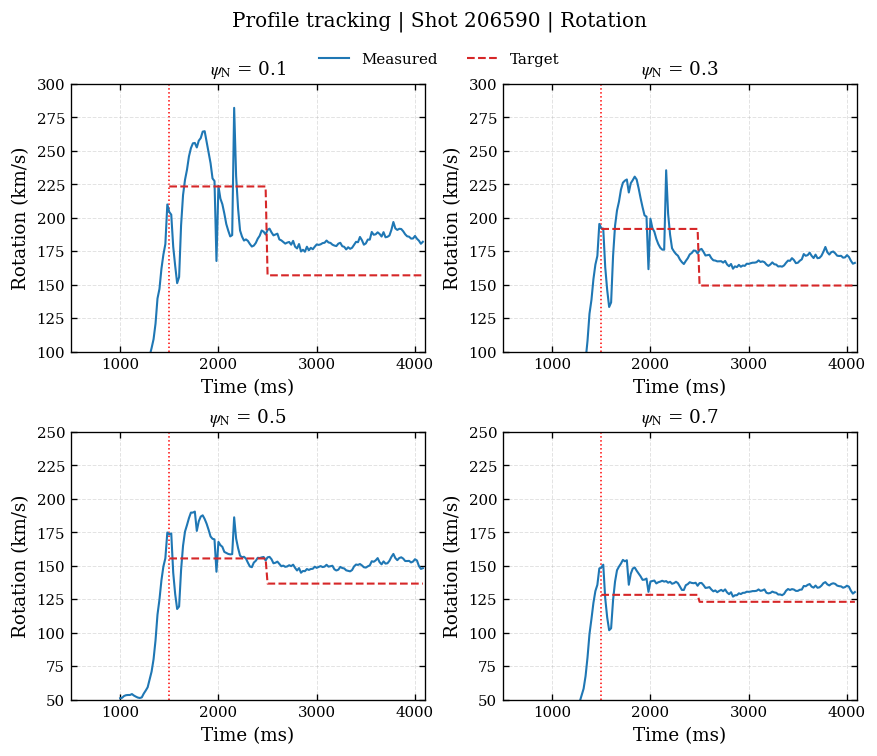

In [167]:
# Figure 1 — profile tracking at four ρ values (2×2)
n_radial = profile_signals.shape[1]
fig1, axes = plt.subplots(2, 2, figsize=(7.2, 5.8), constrained_layout=True)
axes = axes.ravel()

rho_label = r"$\psi_{\mathrm{N}}$" if RHO_CONVENTION == "psi_n" else r"$\sqrt{\psi_{\mathrm{N}}}$"

ylabel_dict = {
    "etemp": "Temperature (keV)",
    "dens": "Density (m$^{-3}$)",
    "pres": "Pressure (Pa)",
    "rot": "Rotation (km/s)",
}
title_dict = {
    "etemp": "Electron Temperature",
    "dens": "Density",
    "pres": "Pressure",
    "rot": "Rotation",
}



# y_limits = (0.8, 4)
RHOS = [0.1, 0.3, 0.5, 0.7]


for idx, (ax, rho) in enumerate(zip(axes, RHOS)):
    rad_idx = rho_to_radial_index(rho, n_radial=n_radial, convention=RHO_CONVENTION)

    x_times_target, target_trace = build_target_trace(
        times=times,
        set_time_indices=set_time_indices,
        targets=targets,
        selected_target_indices=selected_target_indices,
        radial_index=rad_idx,
    )
    x_times_signal = times[plot_start_idx : set_time_indices[-1]]
    signal_trace = profile_signals[plot_start_idx : set_time_indices[-1], rad_idx]
    
    ax.plot(x_times_signal, signal_trace, color="C0", label="Measured")
    ax.plot(x_times_target, target_trace, linestyle="--", color="C3", label="Target")
    # for tset in target_set_times:
        # ax.axvline(tset, color='0.75', linewidth=0.9, linestyle=":", zorder=0) #color="0.75"

    ax.axvline(1500, color='red', linewidth=0.9, linestyle=":", zorder=0)
    ax.set_title(f"{rho_label} = {rho:g}")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylabel_dict[PROF_TYPE])
    ax.grid(True, alpha=0.35, linestyle="--", linewidth=0.6)
    ax.set_xlim(*X_LIMITS_MS)
    # ax.set_ylim(*y_limits)
    ax.set_ylim(*y_limits[idx])
handles, labels = axes[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig1.suptitle(
    f"Profile tracking | Shot {SHOT} | {title_dict[PROF_TYPE]}",
    y=1.06,
)

if SAVE_PDF:
    fig1.savefig(Path(OUT_DIR) / f"{SHOT}_profile_rho_grid_2x2_.pdf")

plt.show()

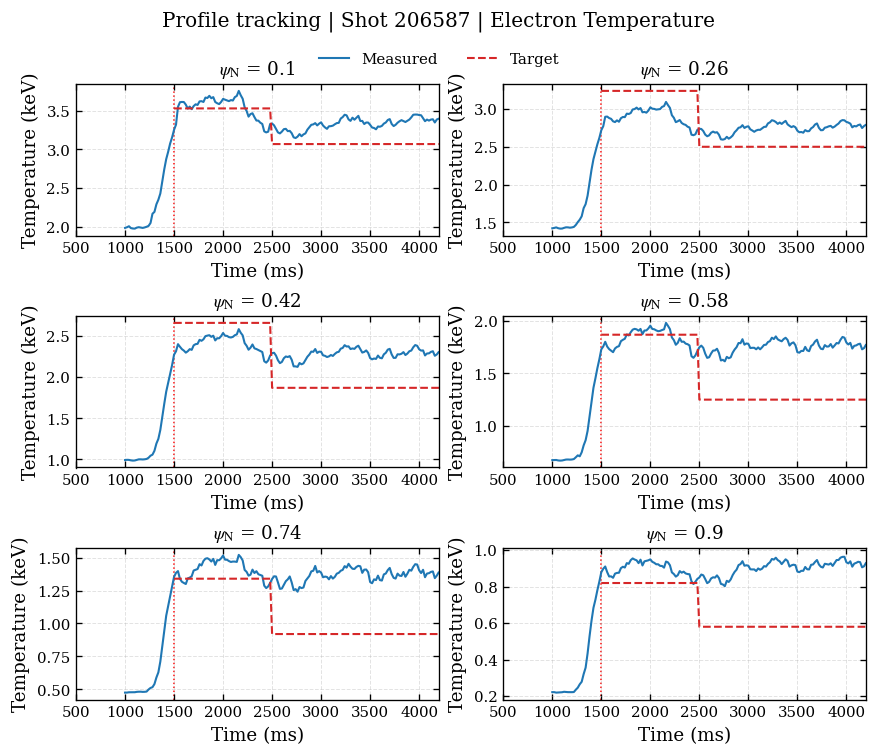

In [92]:
# Figure 1 — profile tracking at four ρ values (2×2)
n_radial = profile_signals.shape[1]
fig1, axes = plt.subplots(3, 2, figsize=(7.2, 5.8), constrained_layout=True)
axes = axes.ravel()

rho_label = r"$\psi_{\mathrm{N}}$" if RHO_CONVENTION == "psi_n" else r"$\sqrt{\psi_{\mathrm{N}}}$"

ylabel_dict = {
    "etemp": "Temperature (keV)",
    "dens": "Density (m$^{-3}$)",
    "pres": "Pressure (Pa)",
    "rot": "Rotation (km/s)",
}

title_dict = {
    "etemp": "Electron Temperature",
    "dens": "Density",
    "pres": "Pressure",
    "rot": "Rotation",
}

RHOS = np.linspace(0.1, 0.9, 6)
# y_limits = (0.4, 4)

for ax, rho in zip(axes, RHOS):
    rad_idx = rho_to_radial_index(rho, n_radial=n_radial, convention=RHO_CONVENTION)

    x_times_target, target_trace = build_target_trace(
        times=times,
        set_time_indices=set_time_indices,
        targets=targets,
        selected_target_indices=selected_target_indices,
        radial_index=rad_idx,
    )
    x_times_signal = times[plot_start_idx : set_time_indices[-1]]
    signal_trace = profile_signals[plot_start_idx : set_time_indices[-1], rad_idx]
    
    ax.plot(x_times_signal, signal_trace, color="C0", label="Measured")
    ax.plot(x_times_target, target_trace, linestyle="--", color="C3", label="Target")
    # for tset in target_set_times:
        # ax.axvline(tset, color='0.75', linewidth=0.9, linestyle=":", zorder=0) #color="0.75"

    ax.axvline(1500, color='red', linewidth=0.9, linestyle=":", zorder=0)
    ax.set_title(f"{rho_label} = {rho:g}")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylabel_dict[PROF_TYPE])
    ax.grid(True, alpha=0.35, linestyle="--", linewidth=0.6)
    ax.set_xlim(*X_LIMITS_MS)
    # ax.set_ylim(*y_limits)

handles, labels = axes[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig1.suptitle(
    f"Profile tracking | Shot {SHOT} | {title_dict[PROF_TYPE]}",
    y=1.06,
)

if SAVE_PDF:
    fig1.savefig(Path(OUT_DIR) / f"{SHOT}_shot_profile_rho_grid_3x2.pdf")

plt.show()